# Customer Churn Prediction Using Gradient Boosting Algorithm

## Student Information
**Student Name:** Muhammad Maaz  
**Roll No:** 1672  

---

## Project Objective
The main objective of this project is to predict customer churn using a supervised machine learning approach.  
The Gradient Boosting Classifier is used to identify customers who are likely to leave a service based on their behavior and account information.

The project aims to:
- Analyze customer behavior patterns.
- Build a predictive machine learning model.
- Evaluate model performance.
- Identify important factors affecting customer churn.

---

## Dataset Description
**Dataset Name:** Customer Churn Dataset

The dataset contains customer-related information such as:
- Customer ID
- Age
- Gender
- Tenure
- Usage Frequency
- Support Calls
- Payment Delay
- Subscription Type
- Contract Length
- Total Spend
- Last Interaction

**Target Variable:**
- Churn (0 = Customer Stayed, 1 = Customer Left)

---

## Machine Learning Algorithm(s) Used
### Gradient Boosting Classifier

Gradient Boosting is a supervised machine learning algorithm used for classification problems.

It creates multiple decision trees sequentially, where each new tree improves the errors made by previous trees.

Advantages:
- High prediction accuracy.
- Handles complex patterns.
- Reduces prediction errors.
- Performs well on structured datasets.

---

## Required Libraries
The following Python libraries are used:

- Pandas → Data loading and manipulation
- NumPy → Numerical operations
- Matplotlib → Data visualization
- Seaborn → Statistical visualization
- Scikit-learn → Machine learning model and evaluation metrics

---

## Instructions to Run the Project

1. Install required libraries:
```
pip install pandas numpy matplotlib seaborn scikit-learn
```

2. Place the dataset CSV file in the same folder as this notebook.

3. Open the notebook using Jupyter Notebook or Google Colab.

4. Run cells in sequence from top to bottom.

5. The notebook will:
- Load the dataset.
- Perform preprocessing.
- Train Gradient Boosting model.
- Evaluate performance.
- Generate predictions.

---

## Expected Output / Results

The notebook will generate:

- Dataset information and preprocessing results.
- Customer churn distribution graph.
- Correlation heatmap.
- Trained Gradient Boosting model.
- Accuracy score.
- Classification report.
- Confusion matrix.
- Feature importance analysis.
- Customer churn prediction results.

The expected outcome is a trained model capable of predicting whether a customer is likely to churn.


# IMPORT LIBERARIES

In [96]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix


## LOAD DATASET

In [97]:
df = pd.read_csv("customer_churn_dataset-testing-master.csv")

print("Dataset Shape:")
print(df.shape)

print("\nFirst 5 Rows:")
print(df.head())


Dataset Shape:
(64374, 12)

First 5 Rows:
   CustomerID  Age  Gender  Tenure  Usage Frequency  Support Calls  \
0           1   22  Female      25               14              4   
1           2   41  Female      28               28              7   
2           3   47    Male      27               10              2   
3           4   35    Male       9               12              5   
4           5   53  Female      58               24              9   

   Payment Delay Subscription Type Contract Length  Total Spend  \
0             27             Basic         Monthly          598   
1             13          Standard         Monthly          584   
2             29           Premium          Annual          757   
3             17           Premium       Quarterly          232   
4              2          Standard          Annual          533   

   Last Interaction  Churn  
0                 9      1  
1                20      0  
2                21      0  
3                1

### DATA INFORMATION 

In [98]:
print("\nDataset Info:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())


Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 64374 entries, 0 to 64373
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   CustomerID         64374 non-null  int64
 1   Age                64374 non-null  int64
 2   Gender             64374 non-null  str  
 3   Tenure             64374 non-null  int64
 4   Usage Frequency    64374 non-null  int64
 5   Support Calls      64374 non-null  int64
 6   Payment Delay      64374 non-null  int64
 7   Subscription Type  64374 non-null  str  
 8   Contract Length    64374 non-null  str  
 9   Total Spend        64374 non-null  int64
 10  Last Interaction   64374 non-null  int64
 11  Churn              64374 non-null  int64
dtypes: int64(9), str(3)
memory usage: 5.9 MB
None

Missing Values:
CustomerID           0
Age                  0
Gender               0
Tenure               0
Usage Frequency      0
Support Calls        0
Payment Delay        0
Subscription T

## DATA CLEANING

In [99]:
#Remove CustomerID because it has no effect on prediction

df.drop("CustomerID", axis=1, inplace=True)

#Remove duplicate rows

df.drop_duplicates(inplace=True)

## ENCODE CATEGORICAL FEATURES

In [79]:
le = LabelEncoder()

df["Gender"] = le.fit_transform(df["Gender"])

df["Subscription Type"] = le.fit_transform(df["Subscription Type"])

df["Contract Length"] = le.fit_transform(df["Contract Length"])

## EXPLORATORY DATA ANALYSIS

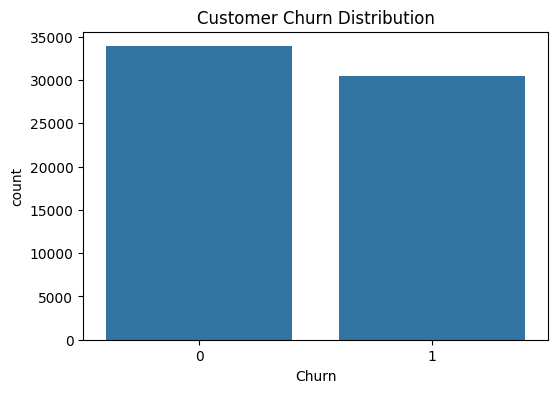

In [80]:
plt.figure(figsize=(6,4))
sns.countplot(x="Churn", data=df)
plt.title("Customer Churn Distribution")
plt.show()

## CORRELATION HEATMAP

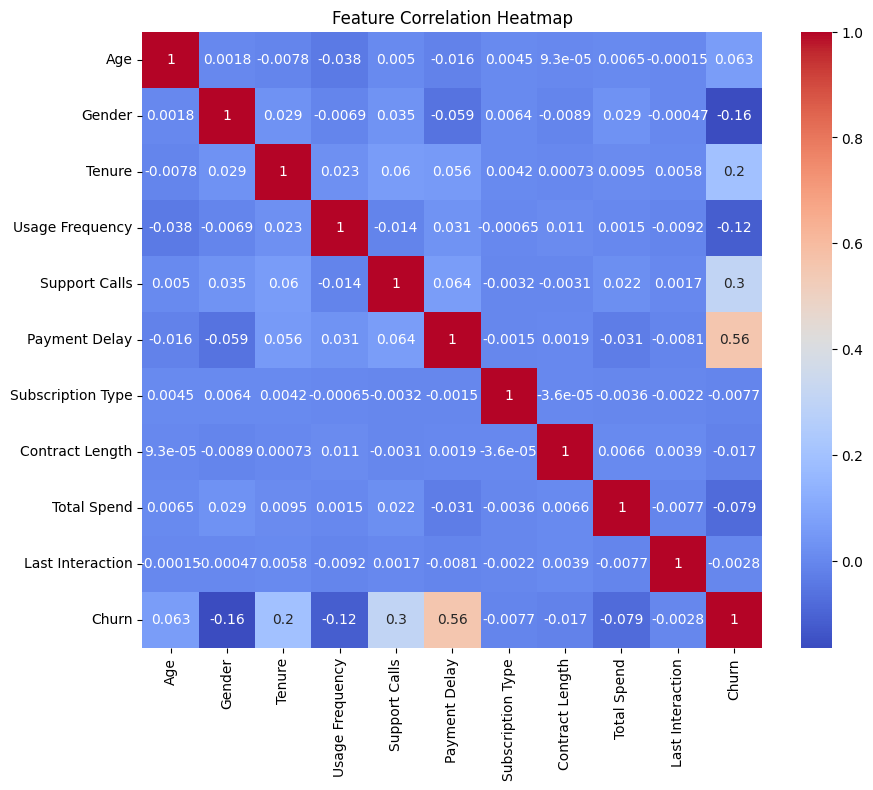

In [81]:
plt.figure(figsize=(10,8))

sns.heatmap(
df.corr(),
annot=True,
cmap="coolwarm"
)

plt.title("Feature Correlation Heatmap")
plt.show()

## FEATURES AND TARGET

In [82]:
X = df.drop("Churn", axis=1)

y = df["Churn"]

## TRAIN TEST SPLIT

In [83]:
X_train, X_test, y_train, y_test = train_test_split(
X,
y,
test_size=0.20,
random_state=42
)

print("\nTraining Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)


Training Shape: (51499, 10)
Testing Shape: (12875, 10)


## GRADIENT BOOSTING MODEL

In [84]:
gb_model = GradientBoostingClassifier(
n_estimators=150,
learning_rate=0.1,
max_depth=3,
random_state=42
)

gb_model.fit(X_train, y_train)

print("\nModel Trained Successfully")


Model Trained Successfully


## PREDICTIONS

In [86]:
y_pred = gb_model.predict(X_test)

## ACCURACY

In [87]:
accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy Score:")
print(round(accuracy * 100, 2), "%")


Accuracy Score:
99.84 %


## CLASSIFICATION REPORT

In [88]:
print("\nClassification Report:\n")

print(classification_report(y_test, y_pred))


Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6793
           1       1.00      1.00      1.00      6082

    accuracy                           1.00     12875
   macro avg       1.00      1.00      1.00     12875
weighted avg       1.00      1.00      1.00     12875



## CONFUSION MATRIX

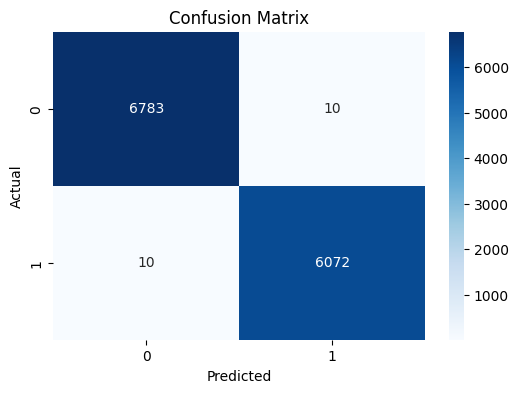

In [89]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
cm,
annot=True,
fmt='d',
cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## FEATURE IMPORTANCE


Feature Importance:
             Feature  Importance
5      Payment Delay    0.436953
4      Support Calls    0.154358
2             Tenure    0.127685
1             Gender    0.094776
3    Usage Frequency    0.084619
0                Age    0.048163
8        Total Spend    0.031501
7    Contract Length    0.019698
6  Subscription Type    0.002248
9   Last Interaction    0.000000


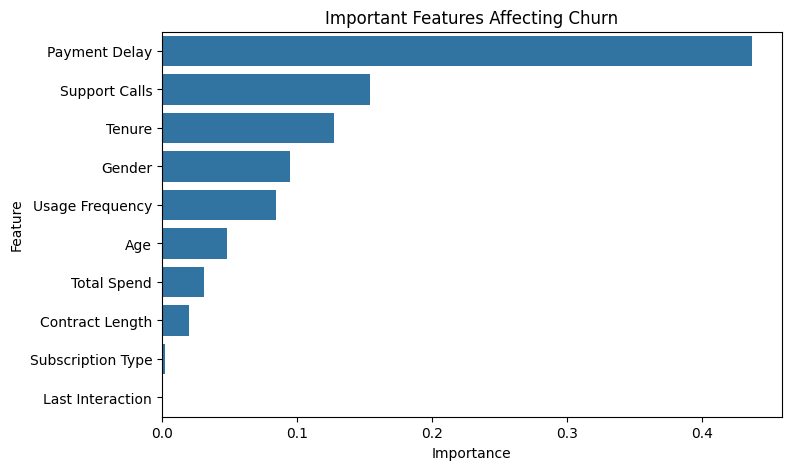

In [90]:
importance = pd.DataFrame({
"Feature": X.columns,
"Importance": gb_model.feature_importances_
})

importance = importance.sort_values(
by="Importance",
ascending=False
)

print("\nFeature Importance:")
print(importance)

plt.figure(figsize=(8,5))

sns.barplot(
data=importance,
x="Importance",
y="Feature"
)

plt.title("Important Features Affecting Churn")
plt.show()

## SAMPLE PREDICTION

In [92]:
sample_customer = X_test.iloc[[0]]

prediction = gb_model.predict(sample_customer)

if prediction[0] == 1:
    print("\nPrediction: Customer Will Churn")
else:
    print("\nPrediction: Customer Will Not Churn")

print("\nPROJECT COMPLETED SUCCESSFULLY")


Prediction: Customer Will Not Churn

PROJECT COMPLETED SUCCESSFULLY
